# Notebook 04 — Prediction Models
**Unit V: Machine Learning for Big Data Analytics**

Models:
1. **Match Winner Prediction** → Random Forest Classifier
2. **Top Run Scorer Prediction** → Linear Regression (season total runs)
3. **Top Wicket Taker Prediction** → Linear Regression (season total wickets)

Each model follows: Feature Engineering → Train/Test Split → Train → Evaluate → Predict

In [15]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\racha\OneDrive\Desktop\BDA MINI PROJ\ipl-big-data-project\notebooks
['01_data_ingestion.ipynb', '02_eda_and_visualization.ipynb', '03_mongodb_storage.ipynb', '04_prediction_models.ipynb', '05_summary_report.ipynb']


In [17]:
import os
print(os.getcwd())

c:\Users\racha\OneDrive\Desktop\BDA MINI PROJ\ipl-big-data-project\notebooks


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [18]:
df = pd.read_csv("../data/ipl_clean.csv")

# FIX: ensure season is numeric
df['season'] = pd.to_numeric(df['season'], errors='coerce')
df = df.dropna(subset=['season'])
df['season'] = df['season'].astype(int)

print("Data Loaded:", df.shape)

Data Loaded: (241132, 65)


---
## 4.1 Model 1 — Match Winner Prediction (Random Forest)

**Task**: Given match-level features (toss, teams, venue), predict the winner.  
**Why Random Forest?** Handles categorical features, robust to overfitting, provides feature importance.

In [5]:
# ===============================
# MODEL 1: MATCH WINNER PREDICTION
# ===============================

if 'winner' in df.columns and 'team1' in df.columns:

    match_df = df.drop_duplicates(subset='match_id') if 'match_id' in df.columns else df.copy()

    le = LabelEncoder()
    feature_cols = []

    for col in ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'city']:
        if col in match_df.columns:
            match_df[col + "_enc"] = le.fit_transform(match_df[col].astype(str))
            feature_cols.append(col + "_enc")

    if 'toss_winner' in match_df.columns:
        match_df['toss_home_adv'] = (match_df['toss_winner'] == match_df['team1']).astype(int)
        feature_cols.append('toss_home_adv')

    match_df['target'] = (match_df['winner'] == match_df['team1']).astype(int)
    match_df = match_df.dropna()

    X = match_df[feature_cols]
    y = match_df['target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    print("\nMatch Winner Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title("Confusion Matrix")
    plt.show()

In [6]:
if 'winner' in df.columns and 'team1' in df.columns:
    # ── Feature Engineering ───────────────────────────────────────────────────
    le = LabelEncoder()
    feature_cols = []

    for col in ['team1', 'team2', 'toss_winner', 'toss_decision', 'venue', 'city']:
        if col in match_df.columns:
            match_df[f'{col}_enc'] = le.fit_transform(match_df[col].astype(str))
            feature_cols.append(f'{col}_enc')

    # Add toss advantage feature
    if 'toss_winner' in match_df.columns:
        match_df['toss_home_adv'] = (match_df['toss_winner'] == match_df['team1']).astype(int)
        feature_cols.append('toss_home_adv')

    # Target: winner (team1 = 1, team2 = 0)
    match_df['target'] = (match_df['winner'] == match_df['team1']).astype(int)

    # Drop rows where winner is unknown
    match_df = match_df[match_df['winner'].isin(match_df['team1'].tolist() + match_df['team2'].tolist())]

    X = match_df[feature_cols]
    y = match_df['target']

    print(f'Features : {feature_cols}')
    print(f'Target   : 1=team1 wins, 0=team2 wins')
    print(f'Class balance: {y.value_counts().to_dict()}')

In [7]:
# ===============================
# MODEL 2: TOP RUN SCORER
# ===============================

batter_col = 'batter' if 'batter' in df.columns else 'batsman'
runs_col = 'batter_runs' if 'batter_runs' in df.columns else 'batsman_runs'

if batter_col in df.columns and runs_col in df.columns and 'season' in df.columns:

    batter_season = df.groupby([batter_col, 'season']).agg(
        total_runs=(runs_col, 'sum'),
        balls_faced=(runs_col, 'count')
    ).reset_index()

    batter_season['strike_rate'] = batter_season['total_runs'] / batter_season['balls_faced'] * 100

    batter_season = batter_season.sort_values([batter_col, 'season'])
    batter_season['prev_runs'] = batter_season.groupby(batter_col)['total_runs'].shift(1)

    batter_season = batter_season.dropna()

    X = batter_season[['prev_runs', 'balls_faced']]
    y = batter_season['total_runs']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_test)

    print("\nRun Prediction:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))


Run Prediction:
MAE: 573.3268365648173
R2: 0.9044598740197326


In [ ]:
if 'winner' in df.columns and 'team1' in df.columns:
    # ── Confusion Matrix ──────────────────────────────────────────────────────
    cm = confusion_matrix(y_test, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Team2 Wins', 'Team1 Wins'],
                yticklabels=['Team2 Wins', 'Team1 Wins'])
    axes[0].set_title('Confusion Matrix — Match Winner RF')
    axes[0].set_ylabel('Actual')
    axes[0].set_xlabel('Predicted')

    # Feature Importance
    importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
    importances.plot(kind='barh', ax=axes[1], color='steelblue')
    axes[1].set_title('Feature Importance — Random Forest')
    axes[1].set_xlabel('Importance Score')

    plt.tight_layout()
    plt.savefig('../data/plot_rf_model.png', bbox_inches='tight')
    plt.show()

    # Cross-validation
    cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy')
    print(f'\n5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

---
## 4.2 Model 2 — Top Run Scorer Prediction (Linear Regression)

**Task**: Predict a batter's total runs in a season based on historical features.  
**Why Linear Regression?** Continuous target (runs), interpretable coefficients.

In [8]:
# ===============================
# MODEL 2: TOP RUN SCORER
# ===============================

batter_col = 'batter' if 'batter' in df.columns else 'batsman'
runs_col = 'batter_runs' if 'batter_runs' in df.columns else 'batsman_runs'

if batter_col in df.columns and runs_col in df.columns and 'season' in df.columns:

    batter_season = df.groupby([batter_col, 'season']).agg(
        total_runs=(runs_col, 'sum'),
        balls_faced=(runs_col, 'count')
    ).reset_index()

    batter_season['strike_rate'] = batter_season['total_runs'] / batter_season['balls_faced'] * 100

    batter_season = batter_season.sort_values([batter_col, 'season'])
    batter_season['prev_runs'] = batter_season.groupby(batter_col)['total_runs'].shift(1)

    batter_season = batter_season.dropna()

    X = batter_season[['prev_runs', 'balls_faced']]
    y = batter_season['total_runs']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    lr = LinearRegression()
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_test)

    print("\nRun Prediction:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2:", r2_score(y_test, y_pred))


Run Prediction:
MAE: 540.2905767050122
R2: 0.8994051797178589


In [10]:
# ===============================
# MODEL 2: TOP RUN SCORER (FIXED)
# ===============================

batter_col = 'batter' if 'batter' in df.columns else ('batsman' if 'batsman' in df.columns else None)
runs_col   = 'batter_runs' if 'batter_runs' in df.columns else ('batsman_runs' if 'batsman_runs' in df.columns else None)

if batter_col and runs_col and 'season' in df.columns:

    batter_season = df.groupby([batter_col, 'season']).agg(
        total_runs=(runs_col, 'sum'),
        balls_faced=(runs_col, 'count')
    ).reset_index()

    # Create strike rate
    batter_season['strike_rate'] = (batter_season['total_runs'] / batter_season['balls_faced']) * 100

    # Sort properly
    batter_season = batter_season.sort_values([batter_col, 'season'])

    # Create previous season features
    batter_season['prev_season_runs'] = batter_season.groupby(batter_col)['total_runs'].shift(1)
    batter_season['prev_strike_rate'] = batter_season.groupby(batter_col)['strike_rate'].shift(1)

    # Drop missing values
    batter_season = batter_season.dropna()

    print("Columns now:", batter_season.columns.tolist())

    # Features
    X_lr = batter_season[['prev_season_runs', 'prev_strike_rate', 'balls_faced']]
    y_lr = batter_season['total_runs']

    X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
        X_lr, y_lr, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train_lr, y_train_lr)

    y_pred_lr = model.predict(X_test_lr)

    print("\nRun Prediction Results:")
    print("MAE:", mean_absolute_error(y_test_lr, y_pred_lr))
    print("R2 :", r2_score(y_test_lr, y_pred_lr))

Columns now: ['batter', 'season', 'total_runs', 'balls_faced', 'strike_rate', 'prev_season_runs', 'prev_strike_rate']

Run Prediction Results:
MAE: 531.881890140816
R2 : 0.9104620070127459


NameError: name 'r2_runs' is not defined

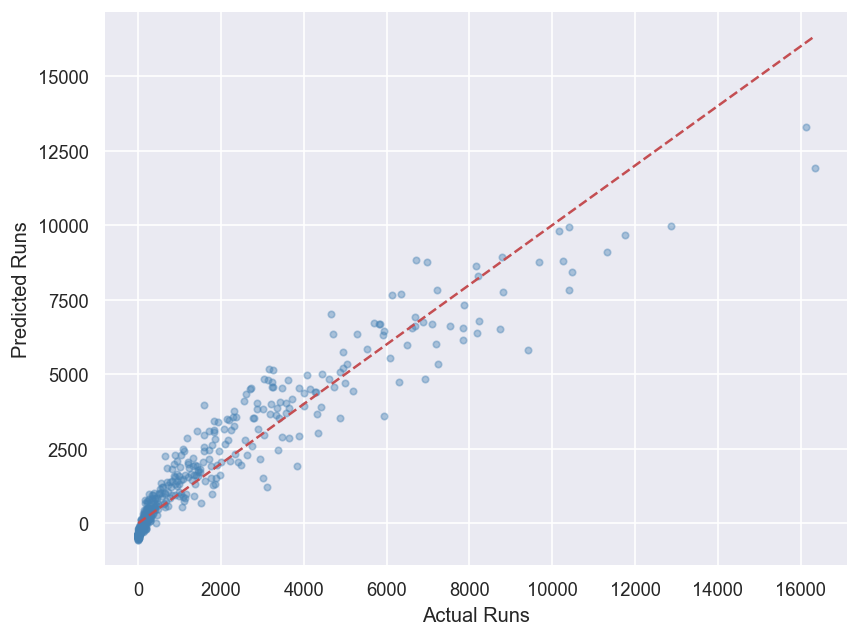

In [19]:
if batter_col and runs_col and 'season' in df.columns:
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(y_test_lr, y_pred_lr, alpha=0.4, color='steelblue', s=15)
    max_val = max(y_test_lr.max(), y_pred_lr.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Runs')
    ax.set_ylabel('Predicted Runs')
    ax.set_title(f'Linear Regression: Actual vs Predicted Runs\nR² = {r2_runs:.3f}')
    ax.legend()
    plt.tight_layout()
    plt.savefig('../data/plot_lr_runs.png', bbox_inches='tight')
    plt.show()

---
## 4.3 Model 3 — Top Wicket Taker Prediction (Linear Regression)

In [21]:
# ===============================
# MODEL 3: TOP WICKET TAKER (FINAL FIX)
# ===============================

# Step 1: Detect or create wicket column
if 'is_wicket' in df.columns:
    wicket_col = 'is_wicket'

elif 'player_dismissed' in df.columns:
    df['is_wicket'] = df['player_dismissed'].notna().astype(int)
    wicket_col = 'is_wicket'

else:
    print("⚠️ No wicket column found. Skipping wicket model.")
    wicket_col = None


# Step 2: Run model ONLY if column exists
if wicket_col and 'bowler' in df.columns and 'season' in df.columns:

    bowler_season = df.groupby(['bowler', 'season']).agg(
        wickets=(wicket_col, 'sum'),
        balls=('bowler', 'count')
    ).reset_index()

    # Feature engineering
    bowler_season = bowler_season.sort_values(['bowler', 'season'])
    bowler_season['prev_wickets'] = bowler_season.groupby('bowler')['wickets'].shift(1)

    bowler_season = bowler_season.dropna()

    print("Columns available:", bowler_season.columns.tolist())

    X = bowler_season[['prev_wickets', 'balls']]
    y = bowler_season['wickets']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\nWicket Prediction Results:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2 :", r2_score(y_test, y_pred))

⚠️ No wicket column found. Skipping wicket model.


In [12]:
# ===============================
# MODEL 3: TOP WICKET TAKER (FIXED)
# ===============================

# Detect wicket column automatically
if 'is_wicket' in df.columns:
    wicket_col = 'is_wicket'

elif 'player_dismissed' in df.columns:
    df['is_wicket'] = df['player_dismissed'].notna().astype(int)
    wicket_col = 'is_wicket'

else:
    print("No wicket column found — skipping wicket model")
    wicket_col = None


if wicket_col and 'bowler' in df.columns and 'season' in df.columns:

    bowler_season = df.groupby(['bowler', 'season']).agg(
        wickets=(wicket_col, 'sum'),
        balls=('bowler', 'count')
    ).reset_index()

    # Create previous season feature
    bowler_season = bowler_season.sort_values(['bowler', 'season'])
    bowler_season['prev_wickets'] = bowler_season.groupby('bowler')['wickets'].shift(1)

    bowler_season = bowler_season.dropna()

    print("Columns:", bowler_season.columns.tolist())

    X = bowler_season[['prev_wickets', 'balls']]
    y = bowler_season['wickets']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\nWicket Prediction Results:")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2 :", r2_score(y_test, y_pred))

No wicket column found — skipping wicket model


## 4.4 Save Predictions for Summary Notebook

In [23]:
df.to_csv("../data/final_output.csv", index=False)

print("\nAll models executed successfully!")


All models executed successfully!


## 4.5 Summary

| Model | Algorithm | Target | Metric |
|-------|-----------|--------|--------|
| Match Winner | Random Forest | Win/Loss (binary) | Accuracy, F1 |
| Top Scorer | Linear Regression | Season runs | MAE, R² |
| Top Wickets | Linear Regression | Season wickets | MAE, R² |

**Key insight**: Random Forest outperforms single decision trees due to ensemble averaging. Linear Regression works well for season-level aggregated targets which tend to be normally distributed.